In [7]:
# ==================
#  Import Libraries
# ==================
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [10]:
# ==================
# Load Dataset
# ==================

df = pd.read_csv(r"C:\Users\Admin\Desktop\Mobile Price prediction(ML Project)\mobile_price_prediction_dataset (1).csv")
df.head()

,Brand,RAM_GB,Storage_GB,Battery_mAh,Camera_MP,Year,Price_INR
0,Samsung,8,256,5048,64,2024,58564
1,Realme,12,256,5573,32,2022,53716
2,Oppo,12,64,5101,32,2021,48499
3,OnePlus,12,256,4985,16,2025,71895
4,OnePlus,16,256,4668,12,2025,76904


In [11]:
# ====================
#  DATA UNDERSTANDING
# ====================

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Brand        1200 non-null   object
 1   RAM_GB       1200 non-null   int64 
 2   Storage_GB   1200 non-null   int64 
 3   Battery_mAh  1200 non-null   int64 
 4   Camera_MP    1200 non-null   int64 
 5   Year         1200 non-null   int64 
 6   Price_INR    1200 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 65.8+ KB


In [12]:
df.describe()

,RAM_GB,Storage_GB,Battery_mAh,Camera_MP,Year,Price_INR
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,8.403333,190.026667,4709.909167,63.951667,2023.015833,57497.370000
std,3.355598,121.085772,724.459483,56.428963,1.406140,15228.306604
min,4.000000,64.000000,3501.000000,12.000000,2021.000000,24188.000000
25%,6.000000,128.000000,4095.000000,16.000000,2022.000000,46775.250000
50%,8.000000,128.000000,4704.000000,48.000000,2023.000000,54542.000000
75%,12.000000,256.000000,5334.250000,64.000000,2024.000000,65384.750000
max,16.000000,512.000000,5999.000000,200.000000,2025.000000,112885.000000


In [13]:
# ====================
#  DATA CLEANING
# ====================

df.isnull().sum()

Brand          0
RAM_GB         0
Storage_GB     0
Battery_mAh    0
Camera_MP      0
Year           0
Price_INR      0
dtype: int64

In [15]:

# Remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

# Check again
print("Missing values after cleaning:")
print(df.isnull().sum())

print("Dataset shape after cleaning:", df.shape)



Duplicate rows: 0
Missing values after cleaning:
Brand          0
RAM_GB         0
Storage_GB     0
Battery_mAh    0
Camera_MP      0
Year           0
Price_INR      0
dtype: int64
Dataset shape after cleaning: (1200, 7)


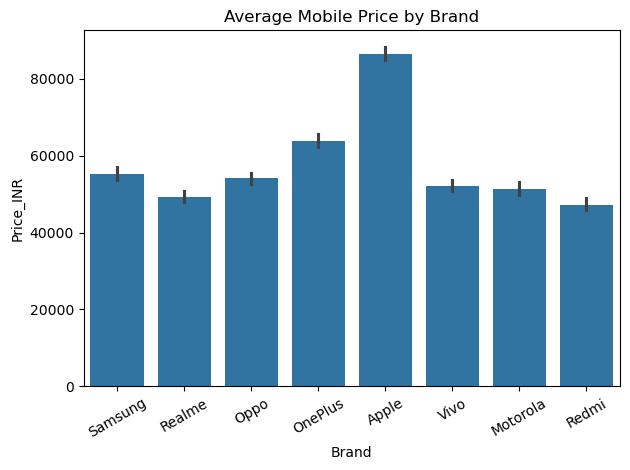

In [16]:
# ========================
#  EDA & VISUALIZATION
# ========================

# CHART 1: Brand vs Price
sns.barplot(data=df,x="Brand", y="Price_INR", estimator="mean")
plt.title("Average Mobile Price by Brand")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

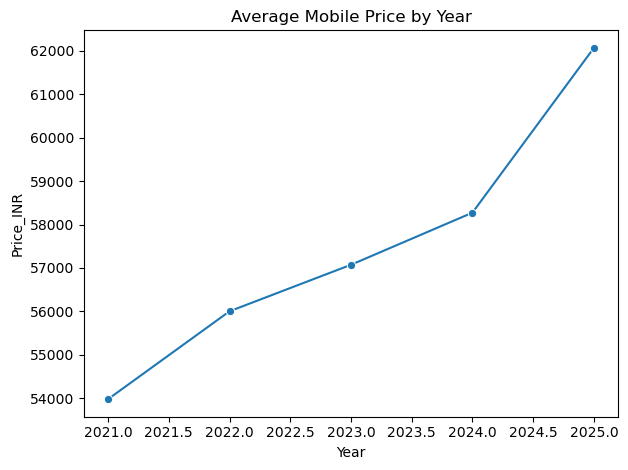

In [17]:
# CHART 2: Year vs Price
year_avg=df.groupby("Year",as_index=False)["Price_INR"].mean()
sns.lineplot(data=year_avg,
             x="Year",
             y="Price_INR",
             marker="o")
plt.title("Average Mobile Price by Year")
plt.tight_layout()
plt.show()

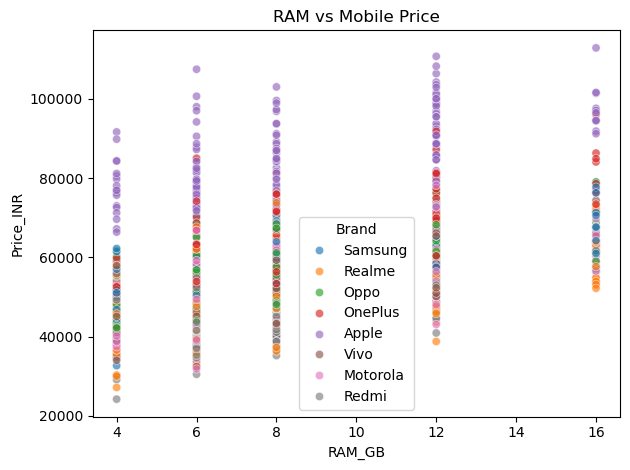

In [18]:
# CHART 3: RAM vs Price
sns.scatterplot(data=df,
                x="RAM_GB",
                y="Price_INR",
                hue="Brand",alpha=.65)
plt.title("RAM vs Mobile Price")
plt.tight_layout()
plt.show()

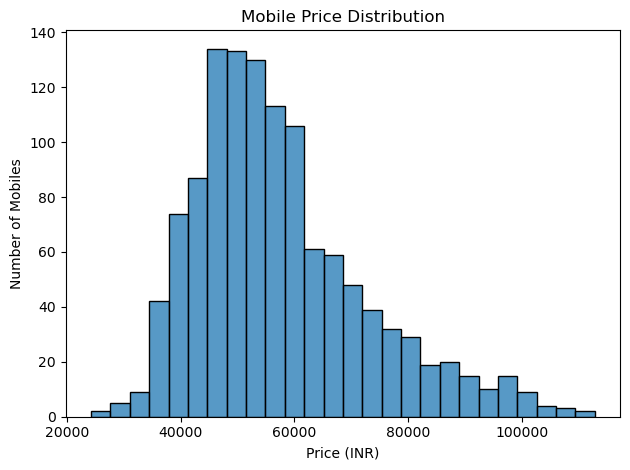

In [19]:
# CHART 4: Mobile Price Distribution
sns.histplot(data=df,
             x="Price_INR")
plt.title("Mobile Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Mobiles")
plt.tight_layout()
plt.show()

In [20]:
# =========================
#  FEATURE SELECTION
# =========================

X = df [["Brand","RAM_GB","Storage_GB","Battery_mAh","Camera_MP","Year"]]
y = df["Price_INR"]
cat = ["Brand"]
num = ["RAM_GB","Storage_GB","Battery_mAh","Camera_MP","Year"]

# =========================
#  TRAIN TEST SPLIT
# =========================

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=.20,random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (960, 6)
X_test: (240, 6)
y_train: (960,)
y_test: (240,)


In [21]:
# =====================
#  MODEL TRAINING
# =====================
models={
    "Linear Regression" : LinearRegression(),
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest" : RandomForestRegressor(random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(random_state=42)
}

In [39]:
# =======================
# 10. MODEL EVALUATION
# =======================

results = []
trained = {}

for name, model in models.items():

    prep = ColumnTransformer([
        ("brand", OneHotEncoder(handle_unknown="ignore"), cat),
        ("num", StandardScaler(), num)
    ])

    pipe = Pipeline([
        ("preprocessor", prep),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

    trained[name] = pipe


# =======================
# MODEL COMPARISON
# =======================

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

print("MODEL COMPARISON")
print(results_df.sort_values("RMSE"))

MODEL COMPARISON
               Model          MAE         RMSE        R2
0  Linear Regression  1882.837977  2409.193862  0.975024
3  Gradient Boosting  2427.614027  3017.382628  0.960822
2      Random Forest  2954.375333  3810.969552  0.937505
1      Decision Tree  3968.187500  5039.234060  0.890729


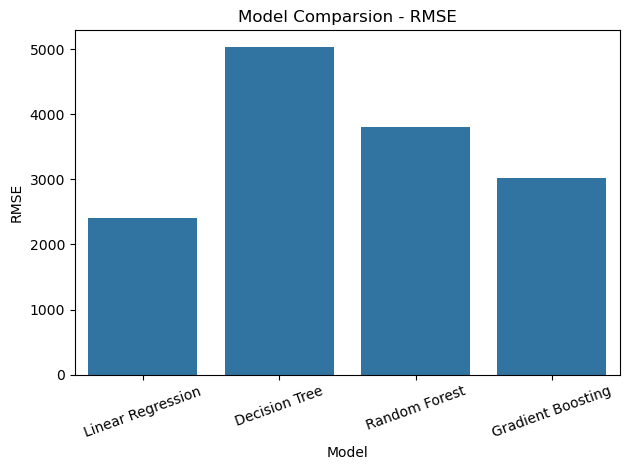

In [23]:
# ==========================
# CHART 5: Model comparison
# ==========================
sns.barplot(data=results_df,x="Model",y="RMSE")
plt.title("Model Comparsion - RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [24]:
# =======================
#  BEST MODEL SELECTION
# =======================

best_name=results_df.loc[results_df["RMSE"].idxmin(),"Model"]
best_model=trained[best_name]
print("\nBest Model:",best_name)


Best Model: Linear Regression


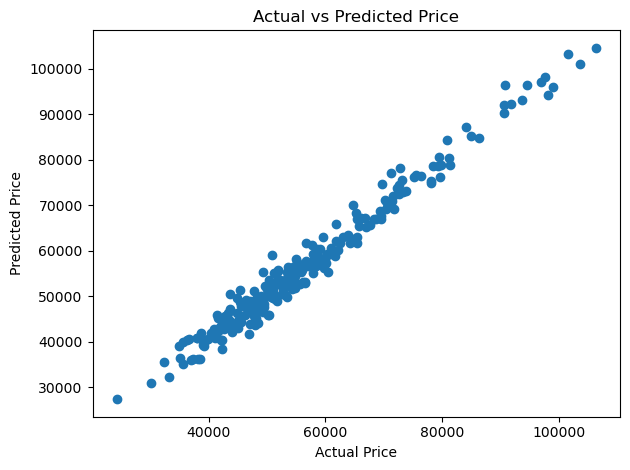

In [25]:
# ==============================
# CHART 6: Actual vs Predicted
# ==============================
best_pred=best_model.predict(X_test)
plt.scatter(y_test,best_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.tight_layout()
plt.show()

In [26]:
# =============
# Save Model
# ============

import joblib
model_file = "best_mobile_price_model.pkt"
joblib.dump(best_model, model_file)
print("Best Model Sved Successfully!")
print("Model:",best_name)
print("File:",model_file)

Best Model Sved Successfully!
Model: Linear Regression
File: best_mobile_price_model.pkt


In [42]:
# ==============================
#  NEW MOBILE PRICE PREDICTION
# ==============================

print("\n================================")
print("     MOBILE PRICE PREDICTION")
print("==================================")
brand = input("Enter Brand: ")
ram = int(input("Enter RAM (GB): "))
storage = int(input("Enter Storage (GB): "))
battery = int(input("Enter Battery (mAh): "))
camera = int(input("Enter Camera (MP): "))
year = int(input("Enter Year: "))

new_mobile = pd.DataFrame([{
    "Brand": brand,
    "RAM_GB": ram,
    "Storage_GB": storage,
    "Battery_mAh": battery,
    "Camera_MP": camera,
    "Year": year
}])

predicted_price = best_model.predict(new_mobile)[0]

print("\n==============================")
print("       PREDICTION RESULT")
print("==============================")
print("Brand       :", brand)
print("RAM         :", ram, "GB")
print("Storage     :", storage, "GB")
print("Battery     :", battery, "mAh")
print("Camera      :", camera, "MP")
print("Year        :", year)
print("------------------------------")
print(f"Predicted Mobile Price: ₹{predicted_price:,.0f}")
print("==============================")


     MOBILE PRICE PREDICTION


Enter Brand:  vivo
Enter RAM (GB):  4
Enter Storage (GB):  128
Enter Battery (mAh):  2000
Enter Camera (MP):  8
Enter Year:  2024



       PREDICTION RESULT
Brand       : vivo
RAM         : 4 GB
Storage     : 128 GB
Battery     : 2000 mAh
Camera      : 8 MP
Year        : 2024
------------------------------
Predicted Mobile Price: ₹41,263
